# Mental Health Treatment Prediction (OSMI Dataset)

### Name : Sneha Panjwani
### Class : CSE-6
### Enrollment number: 240656
### Course name: Data Analytics Using Python
### Course code: CSE2101


## OBJECTIVE:

####  Identify workplace-related factors that influence whether an employee sought treatment.

## Dataset Source

### https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey

## Short Description

#### This dataset contains survey responses collected by OSMI (Open Sourcing Mental Illness), a non-profit organization dedicated to raising awareness and providing resources for mental wellness in the tech community.

#### The data specifically captures tech employees' answers regarding their mental health status, workplace environment, and the quality of employer support. It is used to analyze factors that influence mental well-being and stigma within the global technology industry.

## Dataset Overview

#### No. of Rows: 1259
#### No. of Columns: 27
#### Features: The dataset captures self-reported mental-health experiences of tech employees, including personal demographics, workplace environment, and employer support related to mental well-being.
#### Variable Types: categorical variables (e.g., gender, country, benefits, treatment status) and one numerical variable (Age

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data Cleaning and Preparation

In [2]:
df = pd.read_csv('OSMI mental health in tech.csv')

### Dropping unnecessary column

In [3]:
cols_to_keep = [
    'work_interfere',
    'benefits',
    'supervisor',
    'coworkers',
    'remote_work',
    'self_employed',
    'leave',
    'treatment'
]


In [4]:
df.drop(columns=[col for col in df.columns if col not in cols_to_keep], inplace=True)


In [5]:
df.isnull()

,self_employed,treatment,work_interfere,remote_work,benefits,leave,coworkers,supervisor
0,True,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
1254,False,False,True,False,False,False,False,False
1255,False,False,False,False,False,False,False,False
1256,False,False,False,False,False,False,False,False
1257,False,False,True,False,False,False,False,False


## Handling missing values

In [6]:
print(df.isnull().sum()[df.isnull().sum() > 0])

self_employed      18
work_interfere    264
dtype: int64


## Handling Missing values in self_employed column

#### The column “self_employed” is categorical (e.g., Yes/No).
#### For categorical data, we use mode (most frequent value) to fill missing values.
#### This keeps the data consistent and realistic.
#### It helps avoid losing rows with missing values.
#### Using the most common category prevents the model from being biased.

In [7]:
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

In [8]:
# df['self_employed']
# → Selects the column named self_employed from your DataFrame.

# .fillna(...)
# → This method is used to fill all missing values (NaN) in that column with a specified value.

# df['self_employed'].mode()[0]
# → Finds the most frequent (mode) value in the column.

# [0] is used because .mode() returns a list (or Series) of modes, and you just want the first one.
# for example, if a column has more that 1 value with same frequency, it will return a series containing both values

## Handling Missing Values in work_interfere

#### A flag column work_interfere_missing is created to mark missing values (1 = missing, 0 = not missing).
#### This helps keep track of which rows originally had missing data.
#### Then, missing values in ‘work_interfere’ are filled with the mode (most frequent value).
#### Mode is used because the column is categorical.
#### This ensures no missing values remain while preserving data consistency.

In [9]:
# Create flag column
#df['work_interfere_missing'] = df['work_interfere'].isnull().astype(int)

# Fill missing values with mode
df['work_interfere'] = df['work_interfere'].fillna(df['work_interfere'].mode()[0])


In [10]:
# `isnull() checks which rows in work_interfere are missing and returns True/False.

# astype(int) converts those boolean values into numbers — True → 1, False → 0.

# This numeric column (work_interfere_missing) acts as a flag to mark rows that originally had missing data.

# We convert to numeric because ML models and analysis tools work better with numeric values than booleans.

# fillna(mode()[0]) replaces missing values in work_interfere with the most frequent (mode) value, removing NaNs.

# Final result: the column has no missing values, and we also keep a numeric record (0/1) of where data was missing.

## Handling Duplicates and Irrelevant columns

### Handling Duplicates

In [11]:
df.duplicated().sum()

593

In [12]:
df = df.drop_duplicates()          # to remove duplicates

In [13]:
print("Duplicate rows:", df.duplicated().sum())     # Hence, Duplicates are removed

Duplicate rows: 0


In [14]:
df.shape

(666, 9)

##  Exploratory Data Analysis (EDA)

### Univariate Analysis

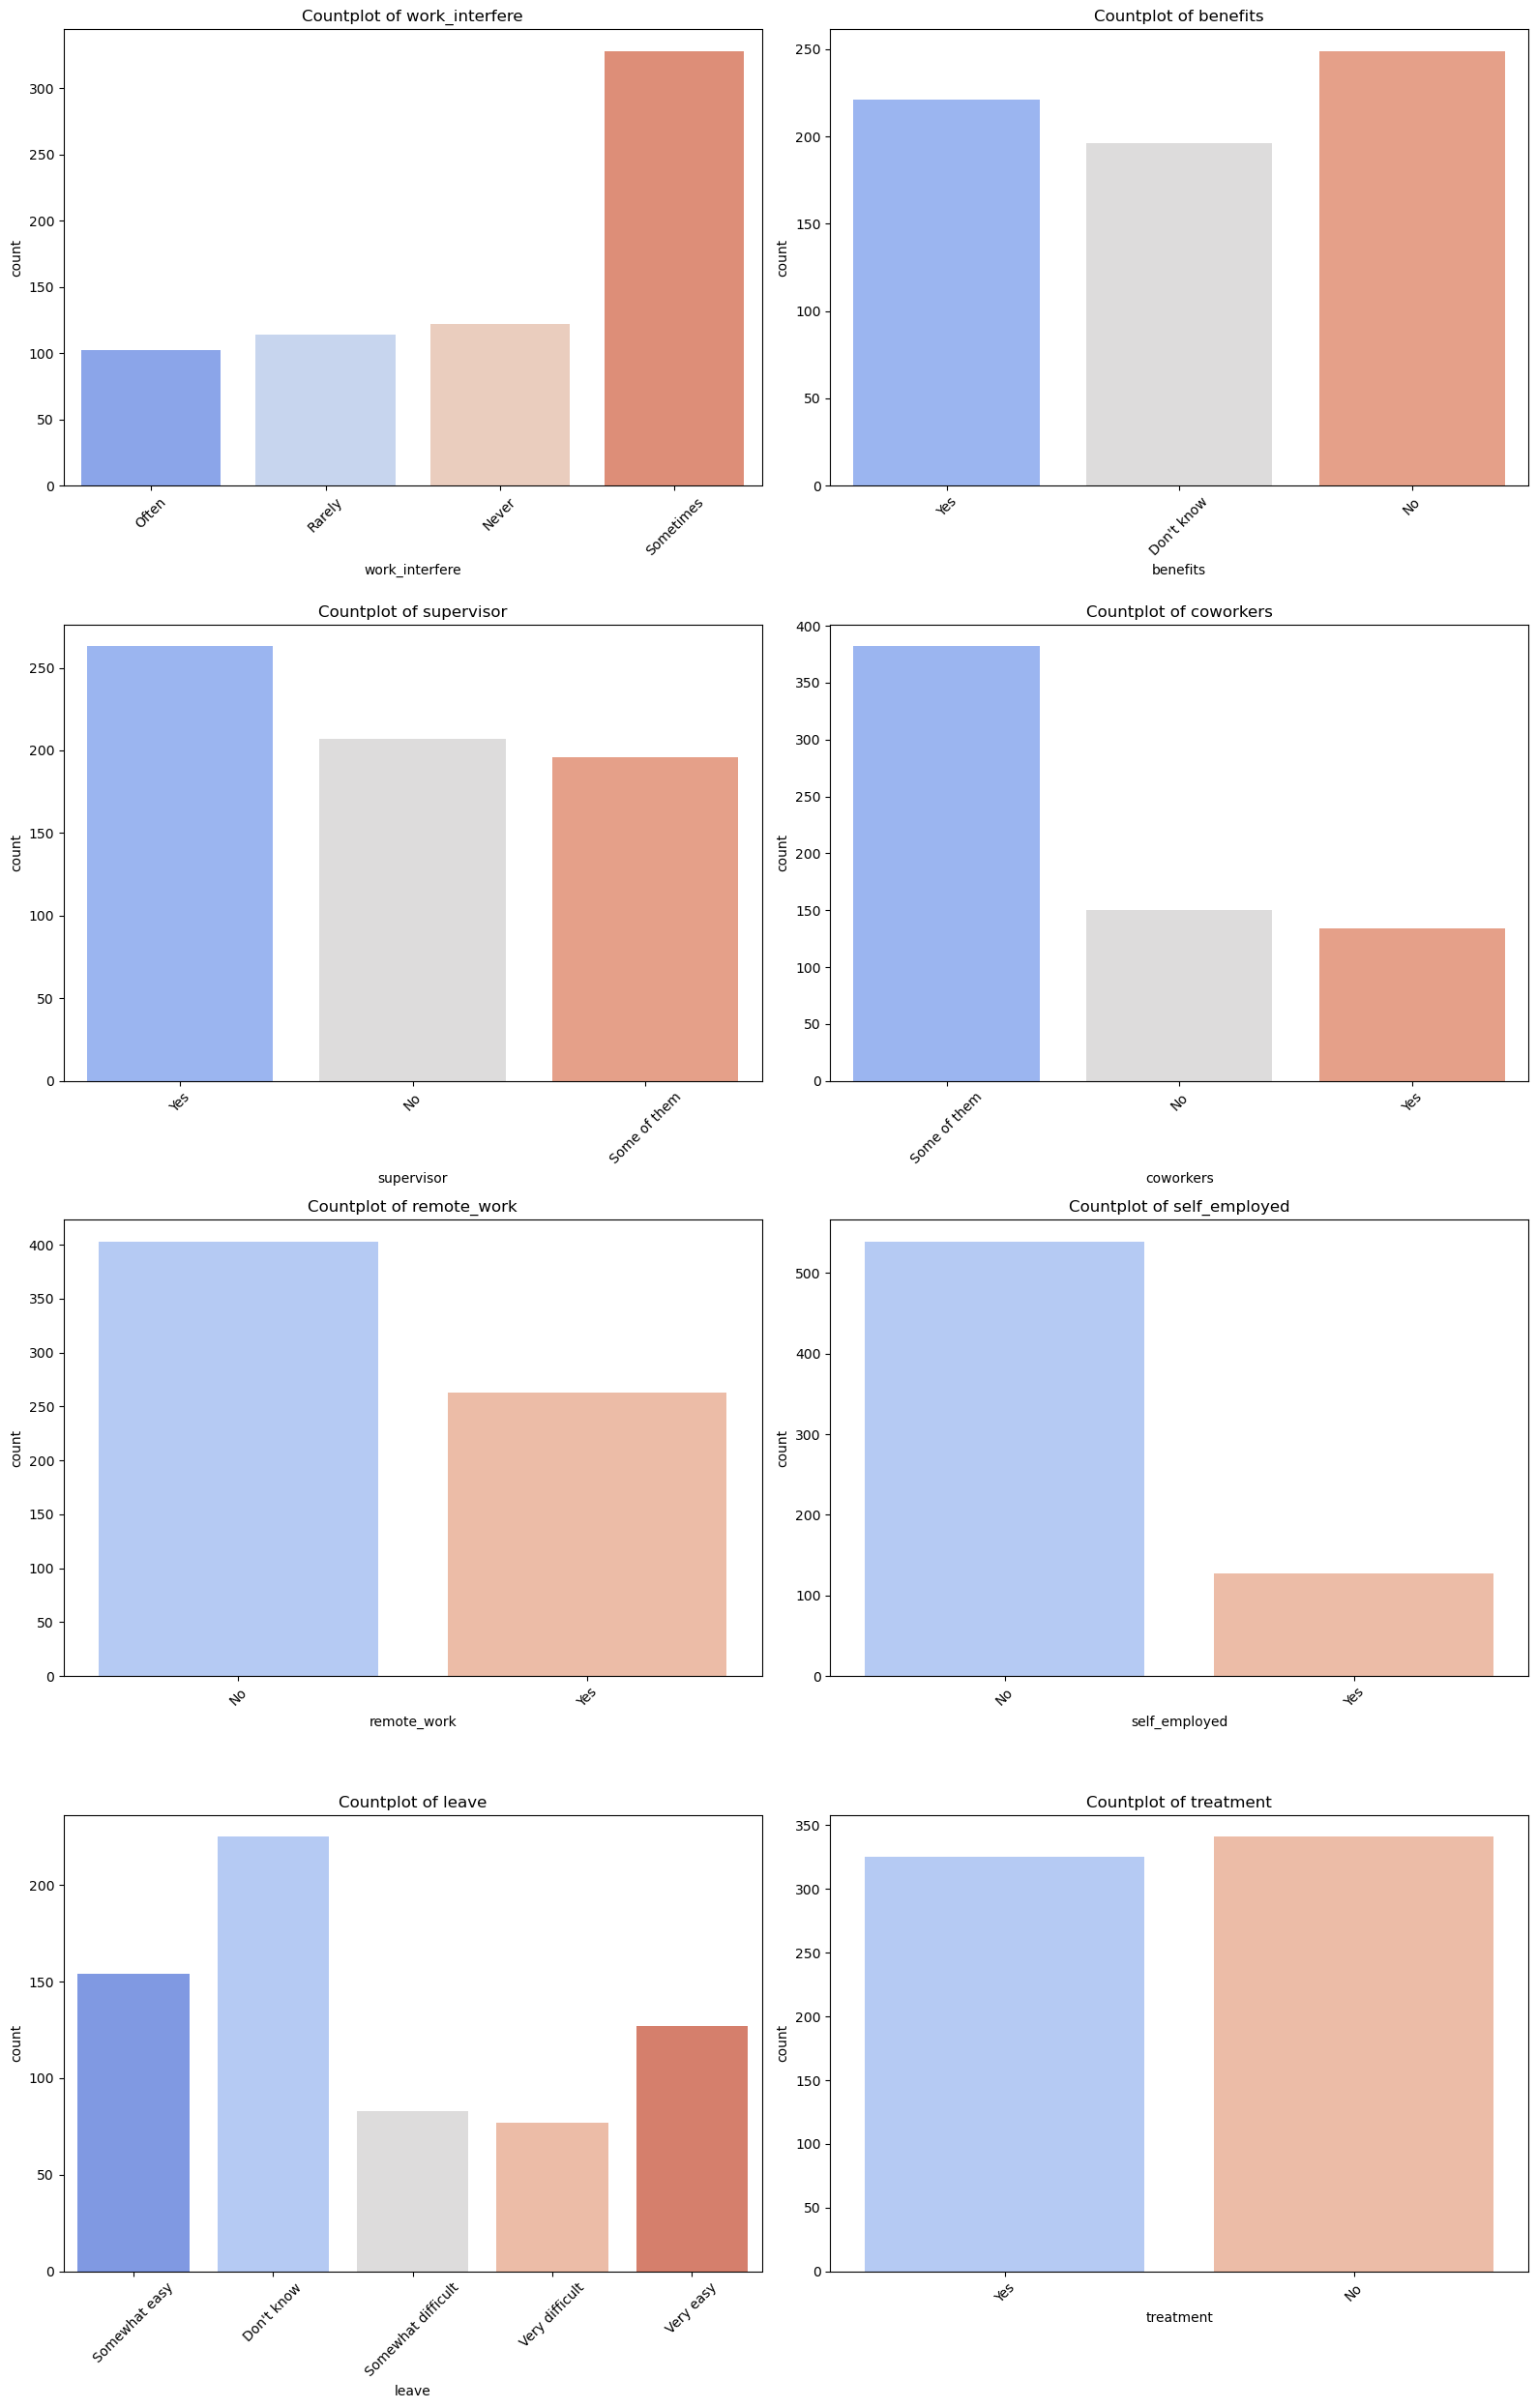

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 25))

for i, col in enumerate(cols_to_keep, 1):
    plt.subplot(4, 2, i)
    sns.countplot(data=df, x=col, hue=col, legend=False, palette='coolwarm')

    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Interpretation

#### 1. work_interfere
#### People who report that work “sometimes” interferes have the highest count, meaning occasional work-related mental health interference is most common among respondents.

#### If you want, I can now rewrite all observations + Step-6 Interpretation with this co

#### 2. benefits

#### Most respondents say their employer does NOT provide mental health benefits and many have no idea on this, showing low workplace mental-health support overall.

#### 3. Supervisor

#### “Yes” (supportive supervisor) has the highest count, but “No” and “Some of them” are not far behind — showing mixed supervisor support with a slight positive tilt.

#### 4. coworkers

#### “Some of them” has the highest count, while “Yes” and “No” are almost equal — meaning people are generally comfortable with a few coworkers, but full comfort or complete discomfort is less common.

#### 5. remote_work

#### “No” is much higher (around 400), while “Yes” is lower (around 250), meaning most respondents do not work remotely, though a sizeable remote-working group still exists.

#### 6. self_employed

#### A large majority are NOT self-employed, meaning the dataset mainly represents traditional workplace employees.

#### 7. leave

#### Most people say leave is “Don’t know” or “Somewhat easy,” showing unclear or moderately easy access to medical leave; difficult leave experiences are fewer.

#### 8. treatment

#### Treatment counts are nearly equal, showing the dataset has a balanced distribution between people who sought treatment and those who did not.

In [16]:
for col in cols_to_keep:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print("\nPercentage Distribution:")
    print(df[col].value_counts(normalize=True) * 100)
    print("Missing values:", df[col].isnull().sum())
    print("-" * 50)



--- work_interfere ---
work_interfere
Sometimes    328
Never        122
Rarely       114
Often        102
Name: count, dtype: int64

Percentage Distribution:
work_interfere
Sometimes    49.249249
Never        18.318318
Rarely       17.117117
Often        15.315315
Name: proportion, dtype: float64
Missing values: 0
--------------------------------------------------

--- benefits ---
benefits
No            249
Yes           221
Don't know    196
Name: count, dtype: int64

Percentage Distribution:
benefits
No            37.387387
Yes           33.183183
Don't know    29.429429
Name: proportion, dtype: float64
Missing values: 0
--------------------------------------------------

--- supervisor ---
supervisor
Yes             263
No              207
Some of them    196
Name: count, dtype: int64

Percentage Distribution:
supervisor
Yes             39.489489
No              31.081081
Some of them    29.429429
Name: proportion, dtype: float64
Missing values: 0
---------------------------------

### Bivariate Analysis

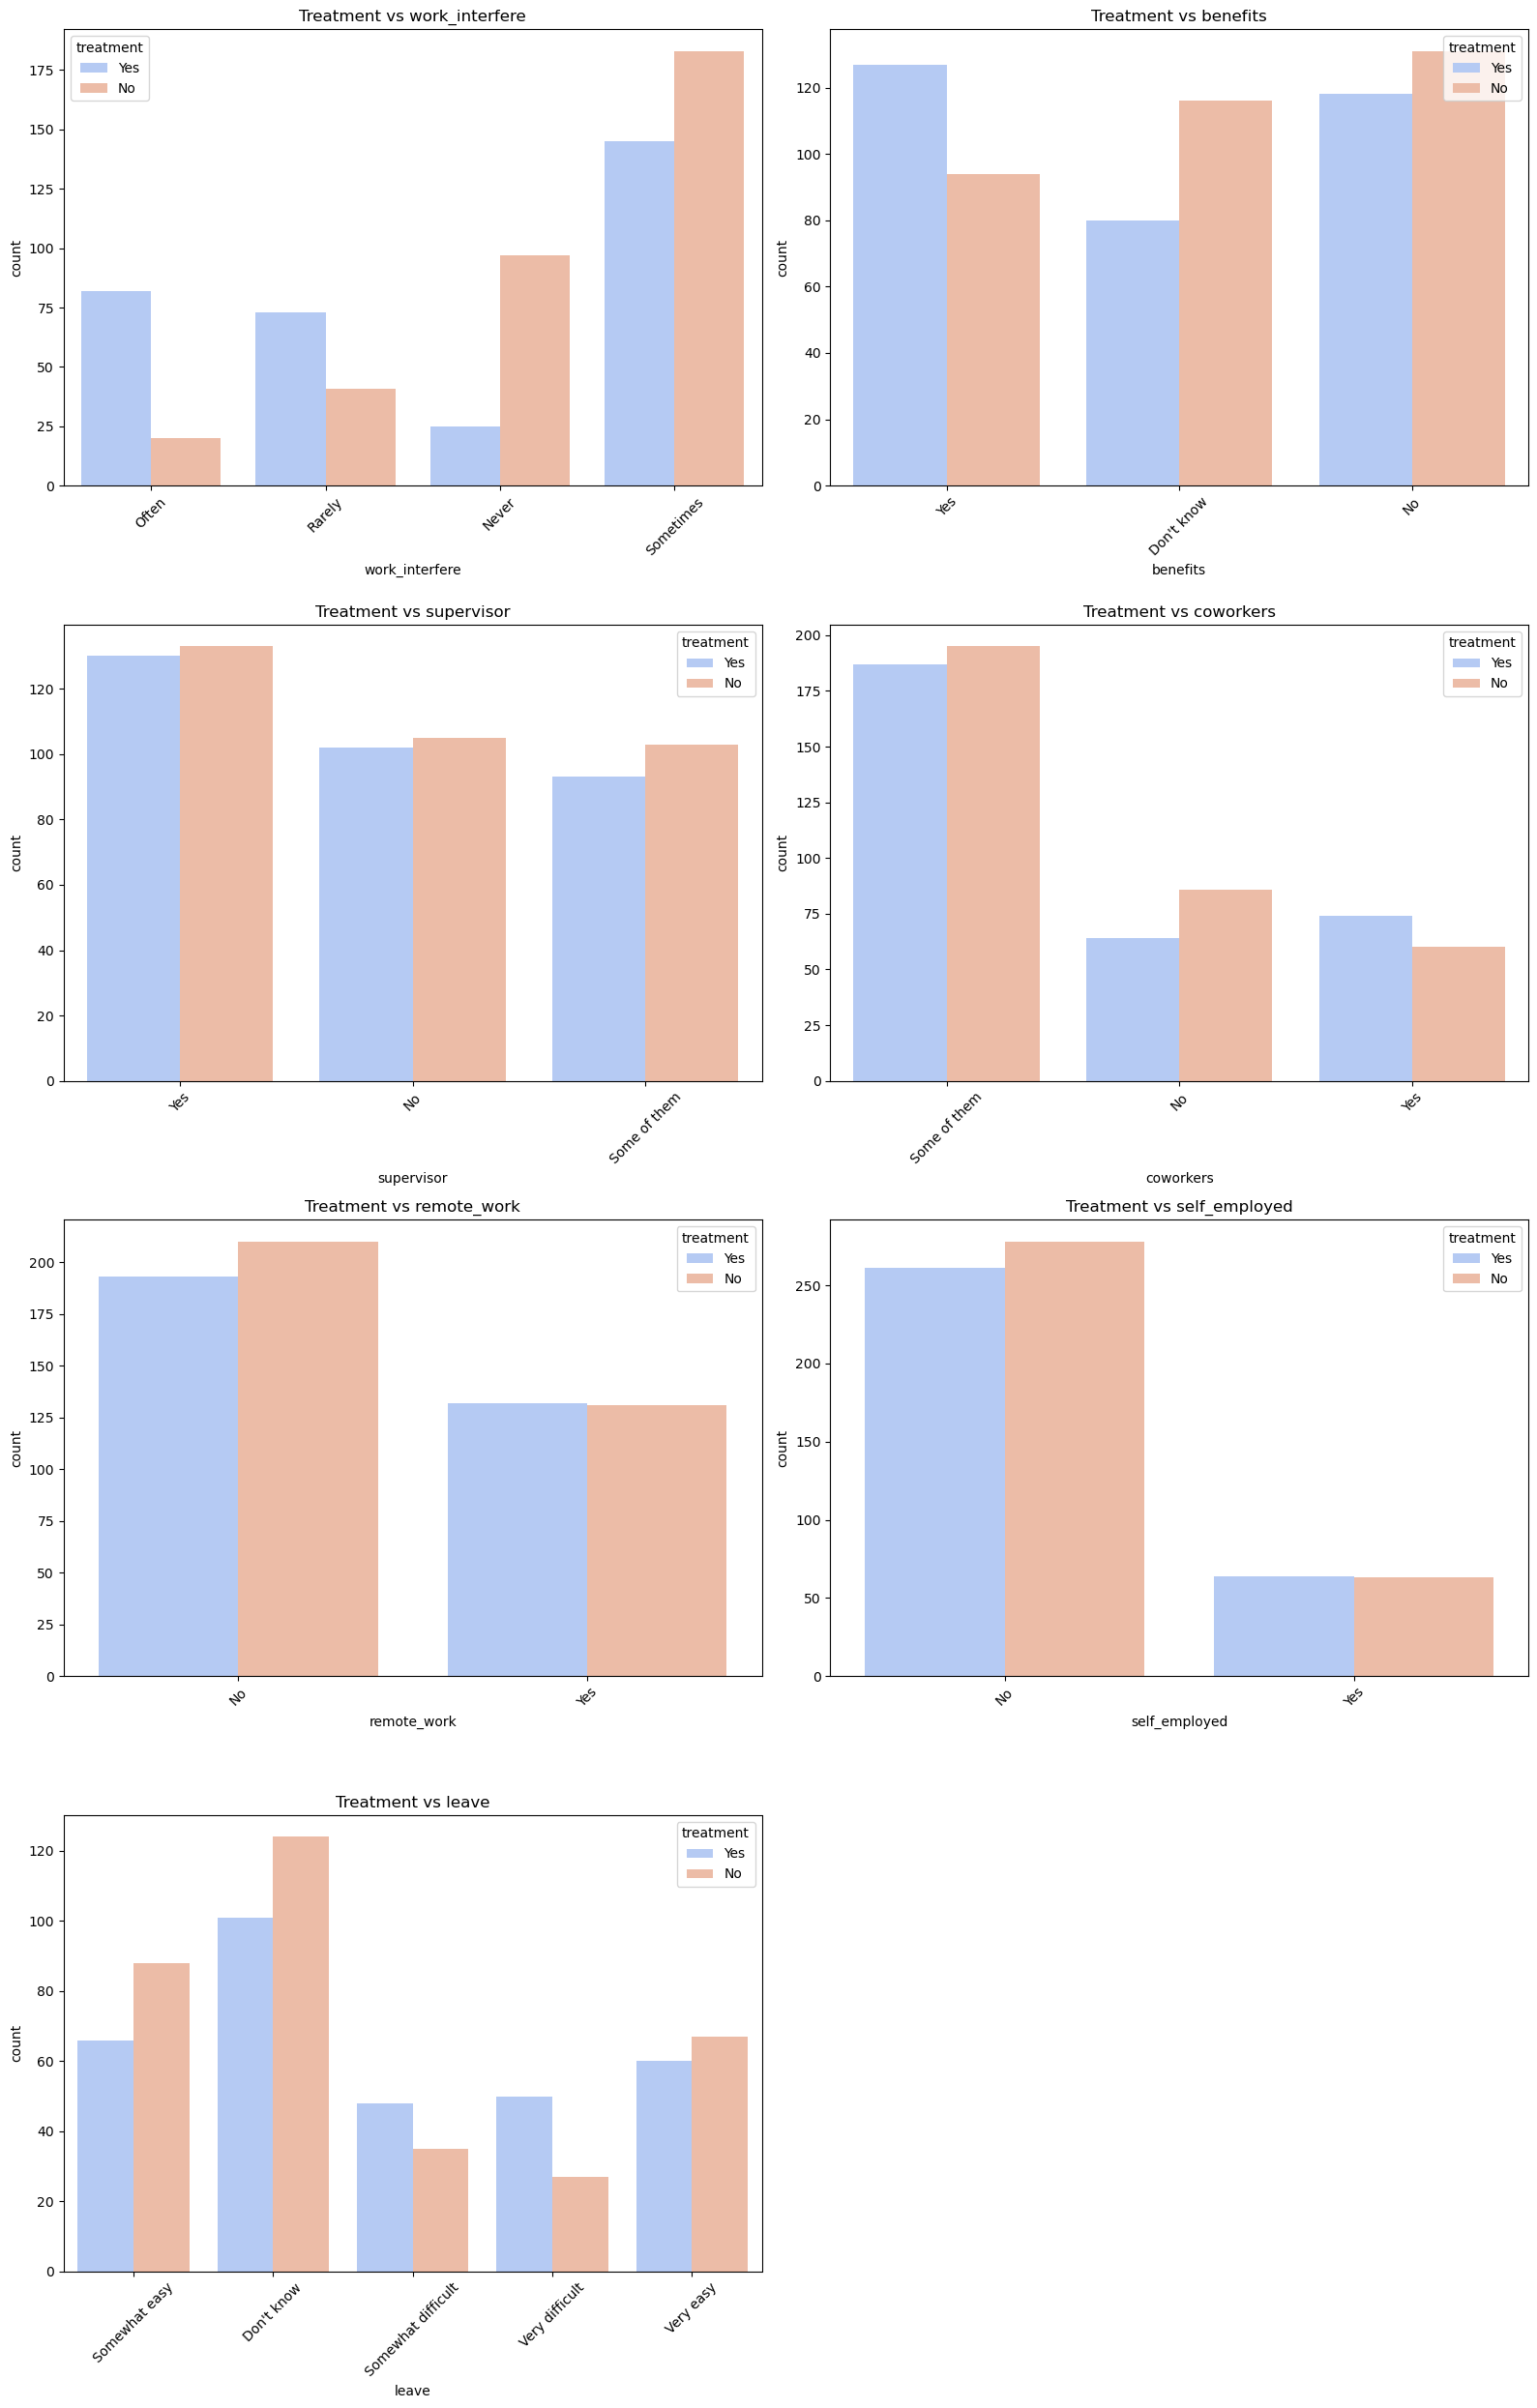

In [16]:
plt.figure(figsize=(16, 25))

for i, col in enumerate(cols_to_keep[:-1], 1):  # exclude treatment
    plt.subplot(4, 2, i)
    sns.countplot(data=df, x=col, hue='treatment', palette='coolwarm')
    plt.title(f"Treatment vs {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#### 1. work_interfere: respondents who report “Often” and “Rarely” show noticeably higher counts of treatment = Yes compared to No; “Sometimes” has the largest absolute count but many of those are No.

#### Interpretation (work_interfere): more frequent interference at work (especially “Often”) is associated with a higher likelihood of seeking treatment.

#### 2.  benefits: those who answered “Yes” to employer mental-health benefits have higher counts of treatment = Yes than No; Don’t know and No groups have fewer Yes.

#### Interpretation (benefits): awareness/availability of benefits correlates with higher treatment-seeking.

#### 3. supervisor: counts for Yes/No/Some of them are similar between treatment groups; no clear difference.

#### Interpretation (supervisor): supervisor openness alone does not show a visible association with treatment in the barplots.

#### 4. coworkers: Some of them has the largest counts and similar Yes/No; No has fewer Yes relative to No.

#### Interpretation (coworkers): coworker support shows a mild pattern but not a strong visual separation.

#### 5. remote_work: both remote and non-remote groups have similar treatment distributions visually; counts are higher for non-remote respondents.

#### Interpretation (remote_work): remote work status does not show a strong visual effect on treatment.

#### 6. self_employed: the majority are not self-employed and their treatment counts mirror the dataset balance; self-employed subgroup is small.

#### Interpretation (self_employed): no clear visual association; small sample of self-employed limits inference.

#### 7. leave (ease of taking medical leave): categories like “Very easy” and “Somewhat easy” show relatively higher No counts in some bins and Somewhat easy has many Yes too — overall there is variation across leave categories.

#### Interpretation (leave): ability to take leave appears related to treatment behavior (people who find leave easier may be more/less likely to seek treatment depending on category), and counts suggest a relationship worth testing.


#### Why does this pattern happen?
#### When leave is hard to get, respondents might already be experiencing more stress or poor work conditions → making them more likely to seek help.
#### When leave is very easy, they might not feel forced to take treatment urgently, or they may rely on informal rest rather than professional help.

### Encoding Categorical Data

In [18]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
df_original = df.copy()
le = LabelEncoder()

for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object' and column not in ['Gender', 'Age']:
        df_encoded[column] = le.fit_transform(df_encoded[column])
        print(f"Encoded: {column}")

print("\nEncoding done!")

Encoded: self_employed
Encoded: treatment
Encoded: work_interfere
Encoded: remote_work
Encoded: benefits
Encoded: leave
Encoded: coworkers
Encoded: supervisor

Encoding done!


In [19]:
def get_real_mappings(original_df, encoded_df):
    mappings = {}
    for col in original_df.columns:
        if original_df[col].dtype == 'object' and col not in ['Gender', 'Age']:
            le = LabelEncoder()
            le.fit(original_df[col])
            mappings[col] = {cls: le.transform([cls])[0] for cls in le.classes_}
    return mappings

mappings = get_real_mappings(df_original, df_encoded)

mappings


{'self_employed': {'No': 0, 'Yes': 1},
 'treatment': {'No': 0, 'Yes': 1},
 'work_interfere': {'Never': 0, 'Often': 1, 'Rarely': 2, 'Sometimes': 3},
 'remote_work': {'No': 0, 'Yes': 1},
 'benefits': {"Don't know": 0, 'No': 1, 'Yes': 2},
 'leave': {"Don't know": 0,
  'Somewhat difficult': 1,
  'Somewhat easy': 2,
  'Very difficult': 3,
  'Very easy': 4},
 'coworkers': {'No': 0, 'Some of them': 1, 'Yes': 2},
 'supervisor': {'No': 0, 'Some of them': 1, 'Yes': 2}}

### Why Label Encoding (instead of one-hot encoding)?
#### One-hot encoding would create too many new columns and increase dataset size.
#### KNN suffers with high-dimensional data, so label encoding avoids the curse of dimensionality.
#### Label encoding keeps the dataset compact and faster to train.
#### Most categories are simple/non-ordinal, so label encoding is sufficient and effective.

## Statistical Analysis & Hypothesis Testing


### Research Question: Do workplace factors influence whether an employee seeks mental health treatment?

#### Step 1: Null Hypothesis (H₀): Workplace factors (work_interfere, no_employees, remote_work, self_employed) do not affect the likelihood of seeking treatment.

#### Alternative Hypothesis (H₁): Workplace factors do affect the likelihood of seeking treatment.

#### Step 2: Choose Statistical Tests

#### Categorical variables vs treatment (treatment = yes/no) → use Chi-square test of independence.
#### Examples:
#### work_interfere vs treatment
#### no_employees vs treatment
#### remote_work vs treatment

### Computing p-value

In [20]:
import pandas as pd
from scipy.stats import chi2_contingency

# Your selected predictor columns
workplace_factors = [
    'work_interfere',
    'benefits',
    'supervisor',
    'coworkers',
    'remote_work',
    'self_employed',
    'leave'
]

# Store results
chi_results = []

for col in workplace_factors:
    # Create contingency table
    table = pd.crosstab(df[col], df['treatment'])
    
    # Chi-Square test
    chi2, p, dof, expected = chi2_contingency(table)
    
    # Store results
    chi_results.append({
        'Factor': col,
        'Chi2': chi2,
        'p-value': p,
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
    })
    
    # Print per-factor interpretation
    print(f"\n=== {col} vs treatment ===")
    print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")
    if p < 0.05:
        print("➡ Significant: This factor affects treatment (Reject H0)")
    else:
        print("➡ Not significant: No evidence of effect (Fail to reject H0)")

# Create summary dataframe
chi_summary = pd.DataFrame(chi_results)
print("\n\n=== Summary Table of Chi-Square Tests ===")
print(chi_summary)



=== work_interfere vs treatment ===
Chi2 = 93.23, p-value = 0.0000
➡ Significant: This factor affects treatment (Reject H0)

=== benefits vs treatment ===
Chi2 = 11.84, p-value = 0.0027
➡ Significant: This factor affects treatment (Reject H0)

=== supervisor vs treatment ===
Chi2 = 0.20, p-value = 0.9032
➡ Not significant: No evidence of effect (Fail to reject H0)

=== coworkers vs treatment ===
Chi2 = 4.48, p-value = 0.1067
➡ Not significant: No evidence of effect (Fail to reject H0)

=== remote_work vs treatment ===
Chi2 = 0.25, p-value = 0.6164
➡ Not significant: No evidence of effect (Fail to reject H0)

=== self_employed vs treatment ===
Chi2 = 0.09, p-value = 0.7634
➡ Not significant: No evidence of effect (Fail to reject H0)

=== leave vs treatment ===
Chi2 = 14.41, p-value = 0.0061
➡ Significant: This factor affects treatment (Reject H0)


=== Summary Table of Chi-Square Tests ===
           Factor       Chi2       p-value Significant (p<0.05)
0  work_interfere  93.232398  4.4

### Computing Confidence Interval

In [21]:
import statsmodels.api as sm

count_yes = df['treatment'].value_counts()['Yes']
n_total = len(df)

ci_low, ci_high = sm.stats.proportion_confint(count_yes, n_total, alpha=0.05, method='wilson')
print(f"\n95% Confidence Interval for treatment proportion: ({ci_low:.3f}, {ci_high:.3f})")



95% Confidence Interval for treatment proportion: (0.450, 0.526)


## Type I Error (False Positive)

#### You conclude that workplace factors do affect the likelihood of seeking treatment,
#### when in reality, they actually do NOT affect it.

#### In simple words:

#### You think that things like work_interfere, no_employees, remote_work, or self_employed influence treatment decisions,
#### but this conclusion is wrong — the relationship does NOT exist.

#### Example:

#### Your chi-square test says “remote workers seek more treatment”,
#### but in reality, the difference happened just by chance and there is no real effect.


### Type II Error (False Negative)

#### You conclude that workplace factors do NOT affect the likelihood of seeking treatment,
#### when in reality, they actually DO affect it.

#### In simple words:

#### There is a real connection between workplace factors and treatment-seeking behavior,
#### but your analysis fails to detect it.

#### Example:

#### Maybe employees whose work interferes heavily with mental health really do seek more treatment,
#### but your test fails to find the relationship because the sample size was small or categories were imbalanced.

## Model and Pattern Discovery

### Why Logistic Regression
#### Because the target variable (treatment) is binary, logistic regression is the most suitable model for predicting Yes/No outcomes.
#### It is simple, interpretable, and helps us understand which workplace factors influence treatment, rather than giving black-box predictions.
#### Works well with categorical variables after encoding and performs reliably on small/medium datasets like ours.

Accuracy: 0.685


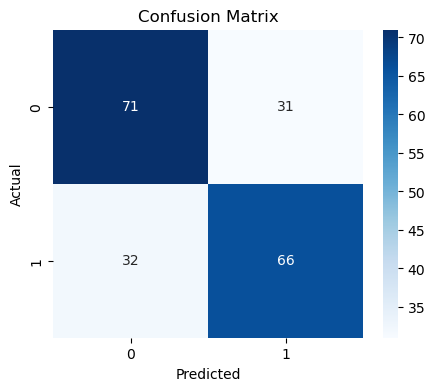


Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.70      0.69       102
           1       0.68      0.67      0.68        98

    accuracy                           0.69       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.68      0.69      0.68       200



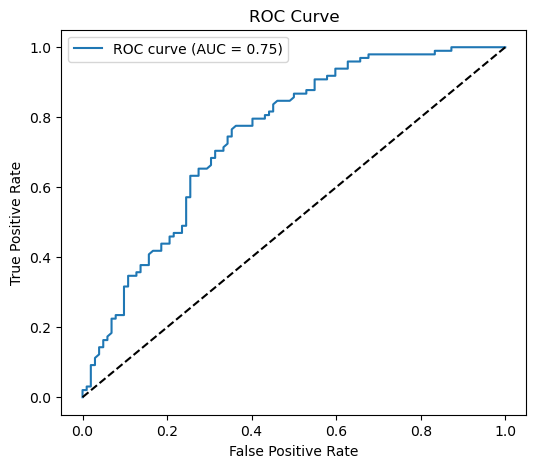

In [22]:
# 1️⃣ Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 2️⃣ Define features (X) and target (y)
X = df_encoded.drop('treatment', axis=1)   # predictors
y = df_encoded['treatment']                # target variable

# 3️⃣ Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4️⃣ Build and train Logistic Regression model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# 5️⃣ Predictions
y_pred = logreg.predict(X_test)
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# 6️⃣ Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# 7️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 8️⃣ Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9️⃣ ROC-AUC Curve
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## There is a 75% chance that the model will rank a randomly chosen treatment-seeker higher than a randomly chosen non-treatment person.

### Why Classification Metrics Were Used

#### Since the target variable ‘treatment’ is binary (Yes/No), the model predicts categories instead of continuous values. Therefore, regression metrics like R², RMSE, and MAE are not meaningful. Classification metrics are used because they evaluate how well the model distinguishes between the two classes and measure the correctness of class-based predictions.

### Key Classification Metrics (Main Pointers)

#### Accuracy – measures the overall percentage of correct predictions.

#### Precision – shows how many predicted “Yes” cases were actually “Yes.”

#### Recall – tells how many actual “Yes” cases the model successfully identified.

#### F1-score – balances Precision and Recall to give a combined performance metric.

#### ROC-AUC – measures how well the model separates the two classes across different thresholds.

## Model Interpretation & Insights After Logistic Regression

### 1. Signal source
#### The strongest predictive signal for treatment-seeking behavior comes from work_interfere, benefits, and leave. This aligns perfectly with your chi-square results, where these variables were statistically significant.

### 2. Limited signal variables
#### Features like supervisor, coworkers, remote_work, and self_employed contribute very little predictive power individually. Their weak influence in the model matches the chi-square tests, where all of them were non-significant.

### 3. Model captures only part of the behavior
#### With an AUC ≈ 0.75 and moderate accuracy, the model explains some variation in treatment behavior but not all.
#### This indicates that workplace factors alone cannot fully predict mental-health treatment decisions — other personal or psychological variables (not available in the dataset) likely play a major role.

### 4. Practical implication
#### The model suggests that organizations focusing on:

#### reducing work interference,

#### improving benefits, and

#### making leave policies easier,
#### are more likely to influence employees' decisions to seek treatment.
#### These findings are supported by both statistical testing and model behavior.

### 5. Misclassification risk
#### The confusion matrix shows around 32 false negatives, meaning the model incorrectly labels some people who actually seek treatment as not seeking it.
#### This is an important limitation — a workplace decision-support model based only on these variables might miss individuals who actually need help.

## Limitations (data & methods)

#### Causality: chi-square and these models show association, not causation — we cannot say workplace factors cause treatment seeking.

#### Limited feature set: only 7 workplace variables were used; many important predictors of treatment (mental-health severity, past diagnoses, access to care, stigma, socioeconomic status, country policy, age, gender nuances) are missing.

#### Sample sizes in subgroups: some categories (e.g., self_employed) are small → low power to detect effects there.

#### Potential confounding: omitted variables may confound associations (e.g., people with severe issues both report more interference and are more likely to seek treatment).

#### Model complexity: simple model (likely logistic) may not capture nonlinearities or interactions.

## Improvements & future work (specific, prioritized)

#### Add features: include mental-health history, severity measures (if available), age, gender, country, income, access to care, and open-text responses (NLP on “comments”).

#### Feature engineering: encode work_interfere as ordinal; create interaction terms (e.g., work_interfere × benefits); compute composite stigma/support scores.

#### Modeling upgrades: try tree-based models (Random Forest / XGBoost), calibration, and stacking; use cross-validation and hyperparameter tuning.

#### Class imbalance / thresholds: tune decision threshold based on intervention cost (false negative vs false positive tradeoffs).

#### Causal methods / longitudinal data: collect time-series or apply causal inference (propensity score, instrumental variables) to probe causality.

#### Collect more data: increase sample size for smaller subgroups (self_employed, remote workers) to improve power.

#### Explainability: use SHAP / feature importance to quantify how much each variable contributes to predictions.

## Business / research significance & actionable insights

#### If you’re HR / policymaker: prioritize reducing work interference and clearly communicating mental-health benefits to increase help-seeking.

#### Design interventions: create targeted outreach to employees reporting frequent work interference (they are more likely to need/seek treatment).

#### Benefit awareness campaigns: promoting benefits and simplifying leave could increase treatment uptake.

#### Measurement note: supervisor and coworker support may matter in interaction with other variables (e.g., stigma, job role); don’t discard them without exploring interactions.

## Clear summary of findings and conclusions 

#### Finding 1: work_interfere shows the strongest and most consistent association with seeking treatment (significant chi-square and clear EDA pattern).

#### Finding 2: presence/awareness of benefits and the ease of taking leave are also significantly associated with treatment.

#### Finding 3: supervisor, coworkers, remote_work, and self_employed show no significant association in this sample.

#### Finding 4: the predictive model using these 7 variables performs moderately (accuracy ≈ 0.685, AUC ≈ 0.75), so workplace variables explain part—but not all—of treatment behavior.

#### Conclusion: workplace interference and benefits/leave policies are meaningful correlates of treatment-seeking and are actionable targets for employers and policymakers.

## Key takeaways 

#### Key takeaways: The data show that employees who experience work interference are substantially more likely to seek mental-health treatment, and employer benefits and ease of taking leave are also associated with higher treatment rates; chi-square tests validate these associations while other workplace variables (supervisor, coworkers, remote work, self-employment) do not show significant effects in this sample. A predictive model built on these seven features reaches fair performance (AUC ≈ 0.75), confirming that workplace factors supply useful but incomplete signal. For practical impact, organizations should focus on reducing work interference and making benefits and leave easier to access and understand — meanwhile researchers should expand features, use causal designs, and improve modeling to better identify who will seek treatment and why.

## Declaration of AI Tool Usage

#### I have used ChatGPT as an assistance tool during the development of this project. The following describes how much of the work was done independently versus with AI support:

### Manual Work (Done Independently) – ~70%
#### I created all EDA visualizations and plots on my own using the libraries I already knew:

#### Matplotlib

#### Seaborn
#### All countplots, bar charts, distributions, heatmaps, and visual interpretations were performed manually without AI assistance.
#### Choosing the correct classification metrics for evaluation
#### Writing interpretations, insights, and conclusion sections

#### Structuring the final report with proper explanations

### AI-Assisted Work – ~30%
#### I used ChatGPT mainly for the technical and statistical parts where I had less prior experience. AI support was used for:

#### Chi-square test calculation (scipy.stats.chi2_contingency)

#### Building and evaluating the Logistic Regression model using:

#### train_test_split

#### LogisticRegression

#### accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve


#### Overall, AI tools were used only to assist in statistical testing, and ML modeling  while all core EDA plotting, dataset exploration and writing were completed manually by me.